In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# processed dataset path
DATA_DIR = Path("dataset/processed_dataset_heavy")

Using device: mps


/Users/jasraj/Desktop/CV_Proj/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Augmentation and Loaders

In [2]:
BATCH_SIZE = 32

class SampleWiseCenter(object):
    def __call__(self, tensor):
        # Subtract this specific image's mean from itself
        return tensor - tensor.mean()

train_transforms = transforms.Compose([
    transforms.Resize((229, 229)),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    SampleWiseCenter(),

    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((229, 229)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    SampleWiseCenter(),

])

train_dataset = datasets.ImageFolder(root=DATA_DIR / 'train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root=DATA_DIR / 'val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(f"Classes loaded: {class_names}")
print(f"Training images: {len(train_dataset)} | Validation images: {len(val_dataset)}")

Classes loaded: ['C', 'D', 'Em', 'F', 'G']
Training images: 1041 | Validation images: 578


## Visualization of Augmentation

RANDOM AUGMENTED TRAINING IMAGES


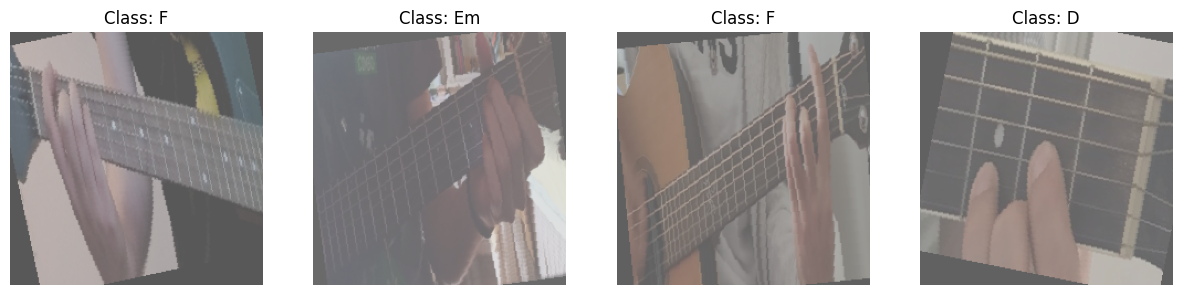

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def unnormalize(tensor):
    tensor = tensor.clone().detach()
    tensor = tensor * 0.5 + 0.5 
    return tensor.clamp(0, 1)

dataiter = iter(train_loader)
images, labels = next(dataiter)

print("RANDOM AUGMENTED TRAINING IMAGES")
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i in range(4):
    img = unnormalize(images[i])
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    
    axes[i].imshow(img_np)
    axes[i].set_title(f"Class: {class_names[labels[i]]}")
    axes[i].axis('off')
plt.show()

## Model Architecture

In [7]:
class GuitarChordClassifier(nn.Module):
    def __init__(self, num_classes):
        super(GuitarChordClassifier, self).__init__()
        
        self.base_model = timm.create_model('inception_resnet_v2', pretrained=True, num_classes=0)
        
        in_features = self.base_model.num_features
        
        # config based on the research paper
        self.custom_tail = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            
            nn.Linear(in_features, 256),  
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.base_model.forward_features(x)
        output = self.custom_tail(features)
        return output

num_classes = len(class_names)
model = GuitarChordClassifier(num_classes=num_classes).to(device)

print(f"Model successfully instantiated with {num_classes} output classes.")

Model successfully instantiated with 5 output classes.


## Dataset Split

In [8]:
train_counts = {class_name: 0 for class_name in class_names}
val_counts = {class_name: 0 for class_name in class_names}

for _, label in train_dataset:
    train_counts[class_names[label]] += 1

for _, label in val_dataset:
    val_counts[class_names[label]] += 1

print("DATASET SPLIT:")
print(f"{'Class':<10} | {'Train':<10} | {'Validation':<10}")
print("-" * 35)
for class_name in class_names:
    print(f"{class_name:<10} | {train_counts[class_name]:<10} | {val_counts[class_name]:<10}")
print("-" * 35)
print(f"{'TOTAL':<10} | {sum(train_counts.values()):<10} | {sum(val_counts.values()):<10}")

DATASET SPLIT:
Class      | Train      | Validation
-----------------------------------
C          | 195        | 120       
D          | 202        | 126       
Em         | 206        | 150       
F          | 219        | 91        
G          | 219        | 91        
-----------------------------------
TOTAL      | 1041       | 578       


## Training Loop

In [ ]:
# hyperparams from the paper
EPOCHS = 200
LEARNING_RATE = 0.001
patience_counter = 0
PATIENCE = 25

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')

print("Starting Training...")

# freeze
for param in model.base_model.parameters():
    param.requires_grad = False

for epoch in range(EPOCHS):
    if(epoch == 25):
        for param in model.base_model.parameters():
            param.requires_grad = True

    # training
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = 100 * correct_train / total_train
    
    # validation
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = 100 * correct_val / total_val
    
    # store past runs
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}%")

    # if weights improve, save them
    if epoch_val_loss < best_val_loss:
        print(f"  Loss improved from {best_val_loss:.4f} to {epoch_val_loss:.4f}. Saving model...")
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'chord_classifier_weights_test_new.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    # scheduler.step(epoch_val_loss)


print("Training Complete! The best weights have been stored.")

Starting Training...
Epoch [1/200] Train Loss: 0.0167, Acc: 99.33% | Val Loss: 0.5923, Acc: 94.12%
  Loss improved from inf to 0.5923. Saving model...
Epoch [2/200] Train Loss: 0.1088, Acc: 99.23% | Val Loss: 0.7016, Acc: 94.98%
Epoch [3/200] Train Loss: 0.0292, Acc: 99.23% | Val Loss: 0.6676, Acc: 94.46%
Epoch [4/200] Train Loss: 0.0167, Acc: 99.42% | Val Loss: 0.6582, Acc: 94.81%
Epoch [5/200] Train Loss: 0.1064, Acc: 99.33% | Val Loss: 0.4613, Acc: 94.81%
  Loss improved from 0.5923 to 0.4613. Saving model...
Epoch [6/200] Train Loss: 0.0158, Acc: 99.52% | Val Loss: 0.4895, Acc: 94.29%
Epoch [7/200] Train Loss: 0.0186, Acc: 99.52% | Val Loss: 0.6027, Acc: 94.46%
Epoch [8/200] Train Loss: 0.0343, Acc: 98.94% | Val Loss: 0.4467, Acc: 94.12%
  Loss improved from 0.4613 to 0.4467. Saving model...
Epoch [9/200] Train Loss: 0.0071, Acc: 99.71% | Val Loss: 0.4101, Acc: 93.94%
  Loss improved from 0.4467 to 0.4101. Saving model...
Epoch [10/200] Train Loss: 0.0507, Acc: 98.56% | Val Loss: 0

KeyboardInterrupt: 

## Plotting Training Curves

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

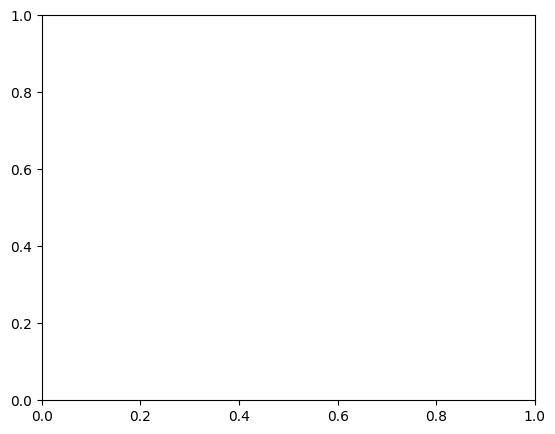

In [7]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## Visualization

In [ ]:
def unnormalize(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    img = std * img + mean
    return np.clip(img, 0, 1)

model.eval()
dataiter = iter(val_loader)
images, labels = next(dataiter)
images_dev, labels_dev = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    _, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(15, 4))
for idx in range(min(4, len(images))):
    ax = fig.add_subplot(1, 4, idx+1, xticks=[], yticks=[])
    img = unnormalize(images[idx])
    ax.imshow(img)
    
    pred_class = class_names[predicted[idx]]
    true_class = class_names[labels[idx]]
    color = "green" if pred_class == true_class else "red"
    
    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}", color=color)

plt.tight_layout()
plt.show()

## Visuals

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Validation Confusion Matrix')
plt.show()

NameError: name 'model' is not defined